In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("Himalayan_Tourism.xlsx")

In [3]:
df.shape

(3000, 13)

In [4]:
df.head(20)

,Record_ID,Year,Month,Destination,State,Tourists,Revenue_Crore,Avg_Stay_Days,Hotel_Occupancy_%,Foreign_Tourists,Adventure_Tourists,Weather_Rating,Satisfaction
0,1,2023,Mar,Ziro Valley,Arunachal,6755,0.61,2.9,71,534,1662,9.0,4.3
1,2,2025,Oct,Rishikesh,Uttarakhand,26639,2.02,5.8,79,2488,10904,8.8,4.4
2,3,2022,Mar,Rishikesh,Uttarakhand,11170,0.83,4.9,76,1120,4511,8.7,4.7
3,4,2024,Jul,Rishikesh,Uttarakhand,12984,0.98,5.1,76,1088,5391,8.9,4.5
4,5,2022,Apr,Tawang,Arunachal,6416,0.58,4.0,71,846,1987,9.1,4.7
5,6,2025,Apr,Nubra Valley,Ladakh,18039,2.40,6.3,79,4903,9986,9.4,4.7
6,7,2021,Jan,Yumthang Valley,Sikkim,5141,0.57,5.0,68,842,1992,9.6,4.9
7,8,2024,Sep,Yumthang Valley,Sikkim,12310,1.43,6.2,71,2349,4118,9.5,4.9
8,9,2021,Nov,Pangong Lake,Ladakh,9882,1.42,4.9,69,2416,5550,9.8,5.0
9,10,2024,Aug,Srinagar,J&K,19656,1.31,2.5,71,3103,3800,9.4,4.5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Record_ID           3000 non-null   int64  
 1   Year                3000 non-null   int64  
 2   Month               3000 non-null   object 
 3   Destination         3000 non-null   object 
 4   State               3000 non-null   object 
 5   Tourists            3000 non-null   int64  
 6   Revenue_Crore       3000 non-null   float64
 7   Avg_Stay_Days       3000 non-null   float64
 8   Hotel_Occupancy_%   3000 non-null   int64  
 9   Foreign_Tourists    3000 non-null   int64  
 10  Adventure_Tourists  3000 non-null   int64  
 11  Weather_Rating      3000 non-null   float64
 12  Satisfaction        3000 non-null   float64
dtypes: float64(4), int64(6), object(3)
memory usage: 304.8+ KB


In [6]:
pd.isnull(df).sum()

Record_ID             0
Year                  0
Month                 0
Destination           0
State                 0
Tourists              0
Revenue_Crore         0
Avg_Stay_Days         0
Hotel_Occupancy_%     0
Foreign_Tourists      0
Adventure_Tourists    0
Weather_Rating        0
Satisfaction          0
dtype: int64

In [7]:
df.columns

Index(['Record_ID', 'Year', 'Month', 'Destination', 'State', 'Tourists',
       'Revenue_Crore', 'Avg_Stay_Days', 'Hotel_Occupancy_%',
       'Foreign_Tourists', 'Adventure_Tourists', 'Weather_Rating',
       'Satisfaction'],
      dtype='object')

In [8]:
df.describe()

,Record_ID,Year,Tourists,Revenue_Crore,Avg_Stay_Days,Hotel_Occupancy_%,Foreign_Tourists,Adventure_Tourists,Weather_Rating,Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,2023.001333,17883.634667,1.558990,4.753467,79.862000,2317.340000,6042.730333,9.025900,4.583433
std,866.169729,1.426187,11492.633227,1.027322,1.334202,10.687518,2065.505376,4949.568344,0.572062,0.275138
min,1.000000,2021.000000,2620.000000,0.230000,2.100000,57.000000,186.000000,527.000000,7.300000,3.800000
25%,750.750000,2022.000000,9757.500000,0.860000,3.600000,72.000000,971.000000,2574.750000,8.700000,4.400000
50%,1500.500000,2023.000000,14934.000000,1.270000,4.700000,78.000000,1685.000000,4603.000000,9.000000,4.600000
75%,2250.250000,2024.000000,22753.250000,1.980000,5.900000,89.000000,2951.250000,7869.500000,9.500000,4.800000
max,3000.000000,2025.000000,81252.000000,9.980000,7.500000,98.000000,21899.000000,45710.000000,10.000000,5.000000


In [9]:
print("Total Tourists:", df["Tourists"].sum())

print("Total Revenue (Crores):", round(df["Revenue_Crore"].sum(),2))

print("Average Stay(Days):", round(df["Avg_Stay_Days"].mean(),2))

print("Average Hotel Occupancy(%):", round(df["Hotel_Occupancy_%"].mean(),2))

print("Average Satisfaction:", round(df["Satisfaction"].mean(),2))

Total Tourists: 53650904
Total Revenue (Crores): 4676.97
Average Stay(Days): 4.75
Average Hotel Occupancy(%): 79.86
Average Satisfaction: 4.58


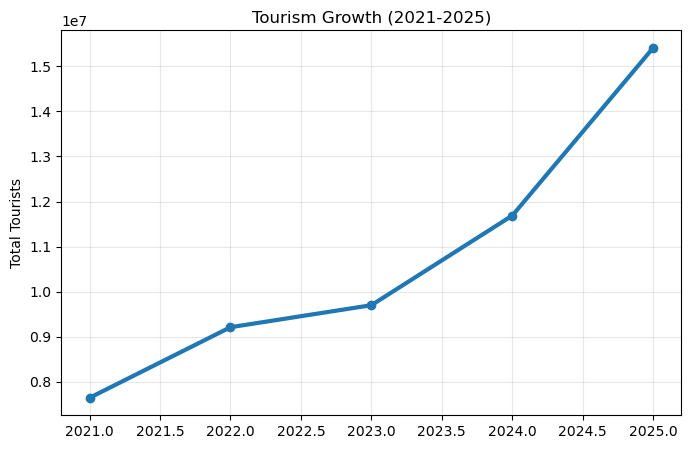

In [10]:
# answers should we expand the business

tourists = df.groupby("Year")["Tourists"].sum()

plt.figure(figsize=(8,5))

plt.plot(tourists.index,
         tourists.values,
         marker='o',
         linewidth=3)

plt.title("Tourism Growth (2021-2025)")

plt.ylabel("Total Tourists")

plt.grid(alpha=.3)

plt.show()

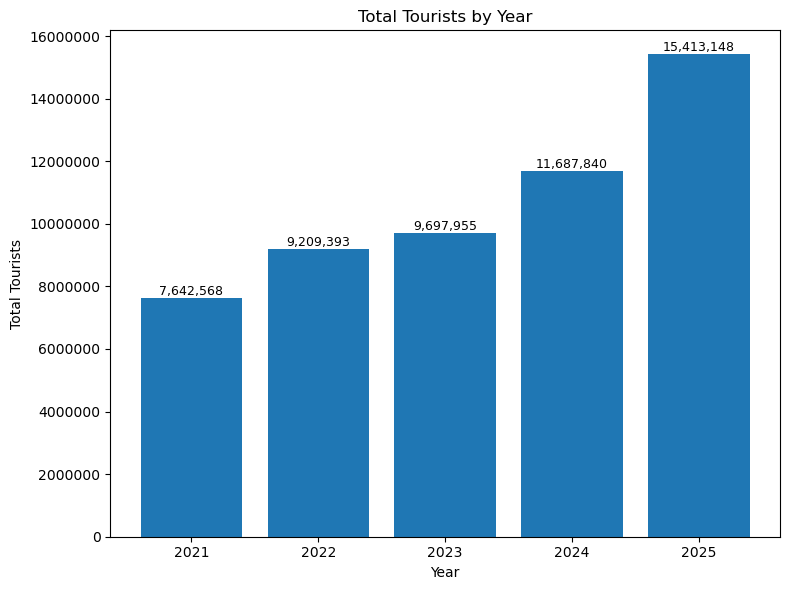

In [11]:
#at what pace the tourists are increasing for future planning

tourists_by_year = df.groupby("Year")["Tourists"].sum().sort_index()

plt.figure(figsize=(8,6))

bars = plt.bar(tourists_by_year.index.astype(str),
               tourists_by_year.values)

plt.xlabel("Year")
plt.ylabel("Total Tourists")
plt.title("Total Tourists by Year")

plt.ticklabel_format(style='plain', axis='y')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

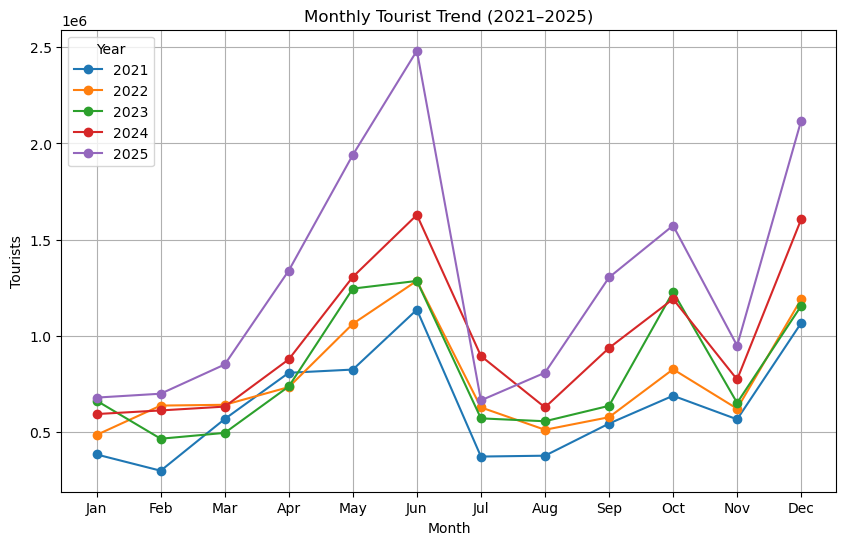

In [12]:
#at what month the business should advertis more

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10,6))

for year in sorted(df["Year"].unique()):
    monthly = (
        df[df["Year"] == year]
          .groupby("Month")["Tourists"]
          .sum()
          .reindex(month_order)
    )

    plt.plot(monthly.index, monthly.values, marker='o', label=year)

plt.title("Monthly Tourist Trend (2021–2025)")
plt.xlabel("Month")
plt.ylabel("Tourists")
plt.legend(title="Year")
plt.grid(True)

plt.show()

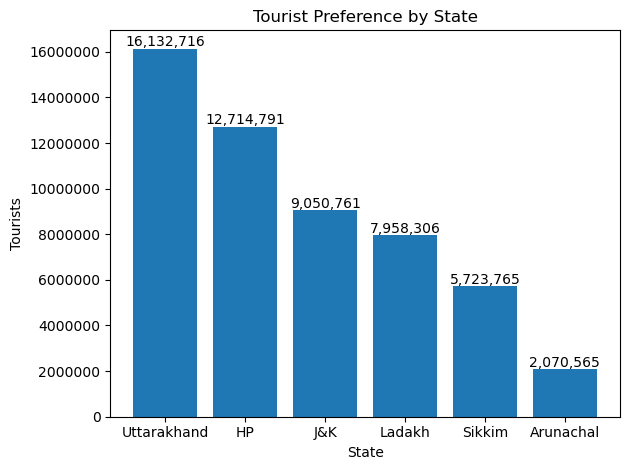

In [13]:
# Identify the states that attract the highest number of tourists.

state = df.groupby("State")["Tourists"].sum().sort_values(ascending=False)

bars = plt.bar(state.index, state.values)

plt.title("Tourist Preference by State")
plt.xlabel("State")
plt.ylabel("Tourists")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100000,
        f"{int(bar.get_height()):,}",
        ha="center"
    )
    
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

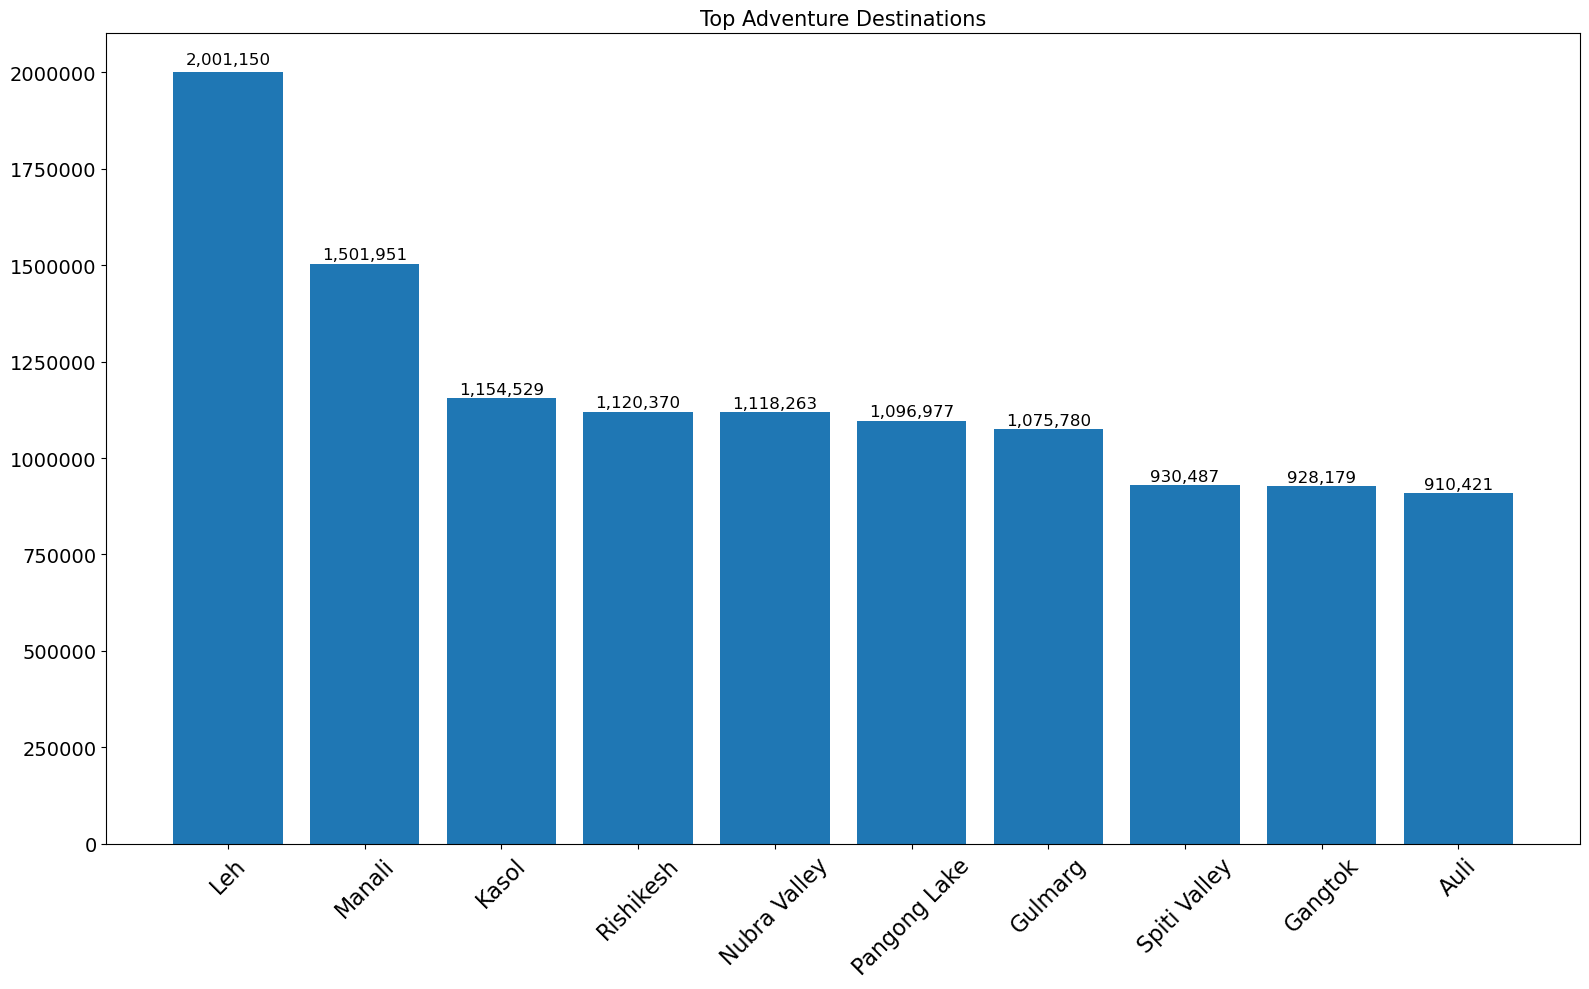

In [14]:
#most popular adventure destinations to help the company design and promote adventure tour packages.

adv=df.groupby("Destination")["Adventure_Tourists"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(16,10))

bars = plt.bar(adv.index, adv.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()*1.01,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=12
    )
    
plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45, fontsize=16)

plt.yticks(fontsize=14)

plt.title("Top Adventure Destinations",fontsize=15)

plt.grid()

plt.tight_layout()

plt.show()

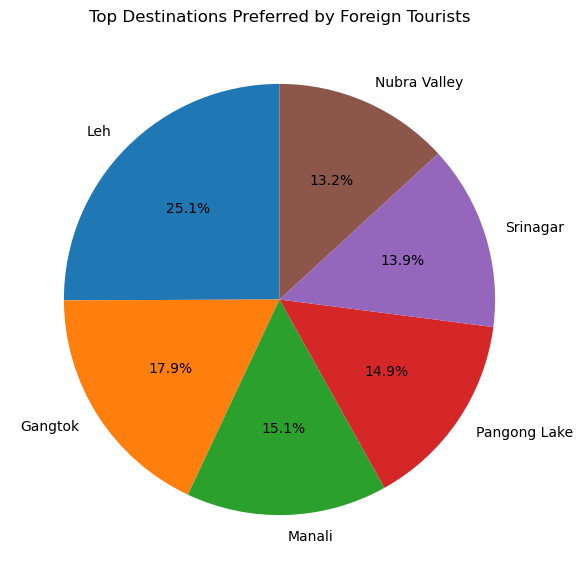

In [15]:
#Destinations preferred by foreign tourists

foreign = df.groupby("Destination")["Foreign_Tourists"].sum()

foreign = foreign.sort_values(ascending=False).head(6)

plt.figure(figsize=(7,7))

plt.pie(foreign.values,
        labels=foreign.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Top Destinations Preferred by Foreign Tourists")

plt.show()

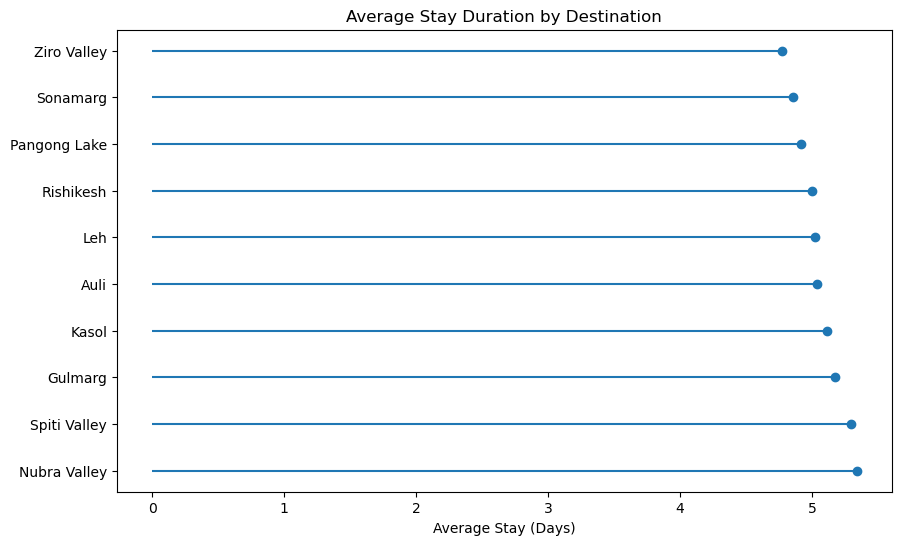

In [16]:
# average stay duration to plan the bookings and advance hotel booking blocks

stay = df.groupby("Destination")["Avg_Stay_Days"].mean()
stay = stay.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.hlines(y=stay.index,
           xmin=0,
           xmax=stay.values)

plt.plot(stay.values,
         stay.index,
         "o")

plt.title("Average Stay Duration by Destination")
plt.xlabel("Average Stay (Days)")

plt.show()